In [63]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.compose import make_column_selector as selector #Para seleccionar de forma automática las variables numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder #Para codificar las variables categóricas usando dummies
from sklearn.preprocessing import StandardScaler #Para normalizar las variables numéricas
from sklearn.compose import ColumnTransformer #Modifica las columnas usando los preprocesadores
from sklearn.pipeline import make_pipeline, Pipeline #Planifica una secuencia de procesos
from sklearn import set_config #Para mostrar graficamente el pipeline
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

train_data = pd.read_csv("./csv/train.csv",  encoding='latin-1')

saleprice_summary = train_data["SalePrice"].describe()

# Calcular percentiles para definir los rangos de clasificación
q1 = train_data["SalePrice"].quantile(0.33)  # 33% más barato
q2 = train_data["SalePrice"].quantile(0.66)  # 66% intermedio
print(q1, q2,  train_data["SalePrice"].max())
train_data_original_ = train_data.copy()


# Crear la nueva variable categórica basada en los percentiles
train_data["PriceCategory"] = pd.cut(train_data["SalePrice"], 
                             bins=[train_data["SalePrice"].min(), q1, q2, train_data["SalePrice"].max()], 
                             labels=[0, 1, 2], #"Económica (0)", "Intermedia(1)", "Cara(2)" 
                             include_lowest=True)

# Mostrar resumen de la variable categórica creada
train_data.head()

139000.0 189893.00000000006 755000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PriceCategory
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,2
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,2
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,1
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,2


# Variable Respuesta

In [36]:
y = train_data.pop("PriceCategory")

print(y)
print(train_data.head())

0       2
1       1
2       2
3       1
4       2
       ..
1455    1
1456    2
1457    2
1458    1
1459    1
Name: PriceCategory, Length: 1460, dtype: category
Categories (3, int64): [0 < 1 < 2]
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...       

# Limpiando la Data

In [37]:
train_data.drop(columns=["Id","Alley","PoolQC", "Fence", "MiscFeature", "Utilities", "FireplaceQu", "GarageYrBlt", "GarageQual", "GarageCond", "MasVnrType"],axis=1, inplace=True)

In [38]:
columns_to_drop = [
    "Neighborhood", "Condition1", "Condition2",
    "RoofMatl", "Exterior1st", "Exterior2nd"
]
train_data.drop(columns=columns_to_drop, inplace=True)

In [39]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 64 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   LotConfig      1460 non-null   object 
 8   LandSlope      1460 non-null   object 
 9   BldgType       1460 non-null   object 
 10  HouseStyle     1460 non-null   object 
 11  OverallQual    1460 non-null   int64  
 12  OverallCond    1460 non-null   int64  
 13  YearBuilt      1460 non-null   int64  
 14  YearRemodAdd   1460 non-null   int64  
 15  RoofStyle      1460 non-null   object 
 16  MasVnrArea     1452 non-null   float64
 17  ExterQual      1460 non-null   object 
 18  ExterCon

# Separacion de train y test

In [40]:
X = train_data #El resto de los datos
random.seed(123)

### 70% entrenamiento y 30% prueba

In [41]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 1052 to 1101
Data columns (total 64 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1021 non-null   int64  
 1   MSZoning       1021 non-null   object 
 2   LotFrontage    823 non-null    float64
 3   LotArea        1021 non-null   int64  
 4   Street         1021 non-null   object 
 5   LotShape       1021 non-null   object 
 6   LandContour    1021 non-null   object 
 7   LotConfig      1021 non-null   object 
 8   LandSlope      1021 non-null   object 
 9   BldgType       1021 non-null   object 
 10  HouseStyle     1021 non-null   object 
 11  OverallQual    1021 non-null   int64  
 12  OverallCond    1021 non-null   int64  
 13  YearBuilt      1021 non-null   int64  
 14  YearRemodAdd   1021 non-null   int64  
 15  RoofStyle      1021 non-null   object 
 16  MasVnrArea     1017 non-null   float64
 17  ExterQual      1021 non-null   object 
 18  ExterCond 

# Modelo con Tangente

In [43]:
#Creamos los selectores
selector_numericas = selector(dtype_exclude=object) #Seleccionamos todas las variables que no son Object
selector_categoricas = selector(dtype_include=object) #Seleccionamos todas las varibles de tipo object
#Seleccionamos las columnas que cumplen con los selectores pasándole los datos
numericas = selector_numericas(train_data)
categoricas = selector_categoricas(train_data)
#veamos que tan bien separó las variables
print("Numéricas: ",numericas)
print("Categóricas: ", categoricas)

Numéricas:  ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categóricas:  ['MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'BldgType', 'HouseStyle', 'RoofStyle', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']


In [44]:
from sklearn.impute import SimpleImputer

preprocesador_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('one_hot_encoder', OneHotEncoder(handle_unknown="ignore"))
])

preprocesador_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('standard_scaler', StandardScaler())
])

In [45]:
preprocesador = ColumnTransformer([
    ('cat', preprocesador_categorico, categoricas),
    ('num', preprocesador_numerico, numericas)
])

In [46]:
modelo = make_pipeline(preprocesador,MLPClassifier(activation="tanh",verbose=True,hidden_layer_sizes=(5,3)))
modelo

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'LotShape', 'LandContour',
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'B...
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageCars', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch', ...])])),
                ('mlpclassifier',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 3),
                               verbose=True))])

In [47]:
modelo.fit(X_train,y_train)

Iteration 1, loss = 1.32024484
Iteration 2, loss = 1.19575769
Iteration 3, loss = 1.10447819
Iteration 4, loss = 1.03962860
Iteration 5, loss = 0.99116813
Iteration 6, loss = 0.94896468
Iteration 7, loss = 0.91051068
Iteration 8, loss = 0.87949074
Iteration 9, loss = 0.85457591
Iteration 10, loss = 0.83379092
Iteration 11, loss = 0.81587011
Iteration 12, loss = 0.79971425
Iteration 13, loss = 0.78475445
Iteration 14, loss = 0.77043418
Iteration 15, loss = 0.75686287
Iteration 16, loss = 0.74362460
Iteration 17, loss = 0.73111283
Iteration 18, loss = 0.71886513
Iteration 19, loss = 0.70668619
Iteration 20, loss = 0.69524383
Iteration 21, loss = 0.68349861
Iteration 22, loss = 0.67221571
Iteration 23, loss = 0.66121840
Iteration 24, loss = 0.65023535
Iteration 25, loss = 0.64005522
Iteration 26, loss = 0.63015576
Iteration 27, loss = 0.62031890
Iteration 28, loss = 0.61121040
Iteration 29, loss = 0.60185769
Iteration 30, loss = 0.59301065
Iteration 31, loss = 0.58418641
Iteration 32, los

c:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'LotShape', 'LandContour',
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'B...
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageCars', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch', ...])])),
                ('mlpclassifier',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 3),
                               verbose=True))])

## Curva de perdida

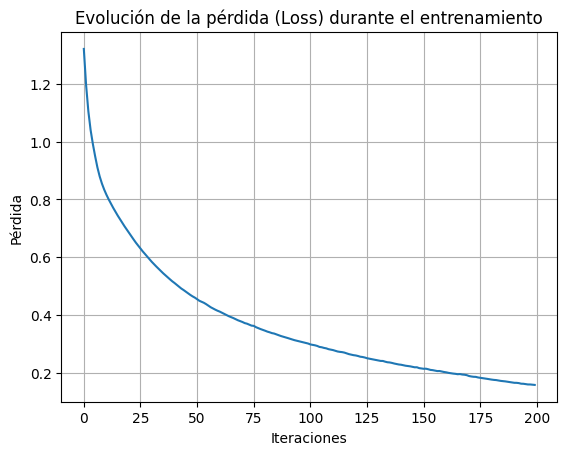

In [48]:
# Acceder al MLPClassifier dentro del pipeline
mlp_final = modelo.named_steps['mlpclassifier']

# Graficar la evolución de la pérdida
plt.plot(mlp_final.loss_curve_)
plt.title('Evolución de la pérdida (Loss) durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid(True)
plt.show()

## Prediccion

In [49]:
pred = modelo.predict(X_test)
pred[:5]

array([2, 1, 0, 0, 2])

Matriz de confusión
 [[133   9   0]
 [ 20 107  14]
 [  0   9 146]]
Accuracy:  0.8812785388127854
Precision:  0.8812785388127854
recall:  0.8812785388127854


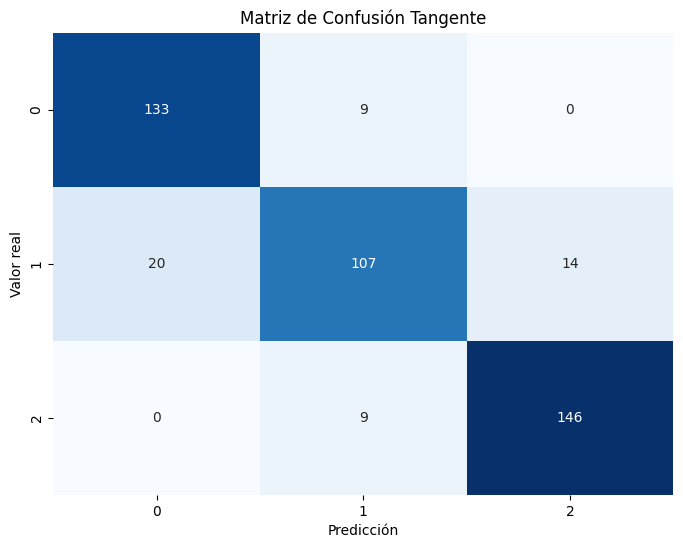

In [50]:
cm = confusion_matrix(y_test,pred)
accuracy=accuracy_score(y_test,pred)
precision =precision_score(y_test,pred,average='micro')
recall =  recall_score(y_test,pred,average='micro')
f1 = f1_score(y_test,pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión Tangente')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

# Modelo Relu

In [51]:
modelo_relu = make_pipeline(preprocesador,MLPClassifier(activation="relu", solver='adam', learning_rate_init=0.001, verbose=True, max_iter=1000, early_stopping=True, hidden_layer_sizes=(10, 6, 3)))
modelo_relu

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'LotShape', 'LandContour',
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'B...
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageCars', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch', ...])])),
                ('mlpclassifier',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(10, 6, 3), max_iter=1000,
                               verbose=True))])

In [52]:
modelo_relu.fit(X_train,y_train)

Iteration 1, loss = 1.35315490
Validation score: 0.310680
Iteration 2, loss = 1.28626862
Validation score: 0.300971
Iteration 3, loss = 1.22734856
Validation score: 0.310680
Iteration 4, loss = 1.17099767
Validation score: 0.349515
Iteration 5, loss = 1.11922970
Validation score: 0.398058
Iteration 6, loss = 1.07359501
Validation score: 0.407767
Iteration 7, loss = 1.03803829
Validation score: 0.446602
Iteration 8, loss = 1.01149656
Validation score: 0.456311
Iteration 9, loss = 0.98951714
Validation score: 0.436893
Iteration 10, loss = 0.96944759
Validation score: 0.456311
Iteration 11, loss = 0.95105278
Validation score: 0.485437
Iteration 12, loss = 0.93283892
Validation score: 0.485437
Iteration 13, loss = 0.91533685
Validation score: 0.485437
Iteration 14, loss = 0.89926945
Validation score: 0.485437
Iteration 15, loss = 0.88545333
Validation score: 0.485437
Iteration 16, loss = 0.87288696
Validation score: 0.495146
Iteration 17, loss = 0.86145056
Validation score: 0.495146
Iterat

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'LotShape', 'LandContour',
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'B...
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageCars', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch', ...])])),
                ('mlpclassifier',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(10, 6, 3), max_iter=1000,
                               verbose=True))])

## Curva de perdida

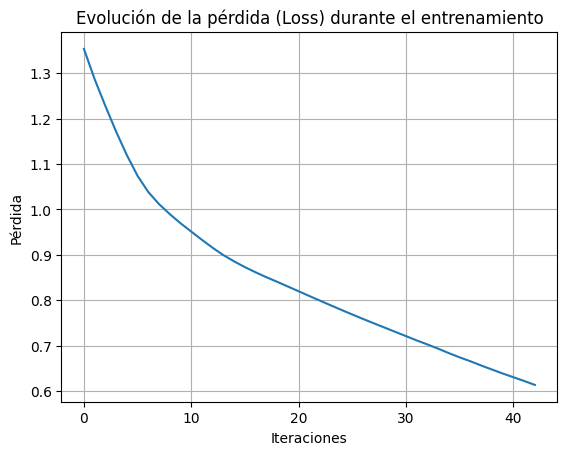

In [53]:
# Acceder al MLPClassifier dentro del pipeline
mlp_final = modelo_relu.named_steps['mlpclassifier']

# Graficar la evolución de la pérdida
plt.plot(mlp_final.loss_curve_)
plt.title('Evolución de la pérdida (Loss) durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid(True)
plt.show()

## Prediccion

In [54]:
pred = modelo_relu.predict(X_test)
pred[:5]

array([2, 1, 1, 1, 2])

Matriz de confusión
 [[  0 141   1]
 [  0 115  26]
 [  0  16 139]]
Accuracy:  0.5799086757990868
Precision:  0.5799086757990868
recall:  0.5799086757990868


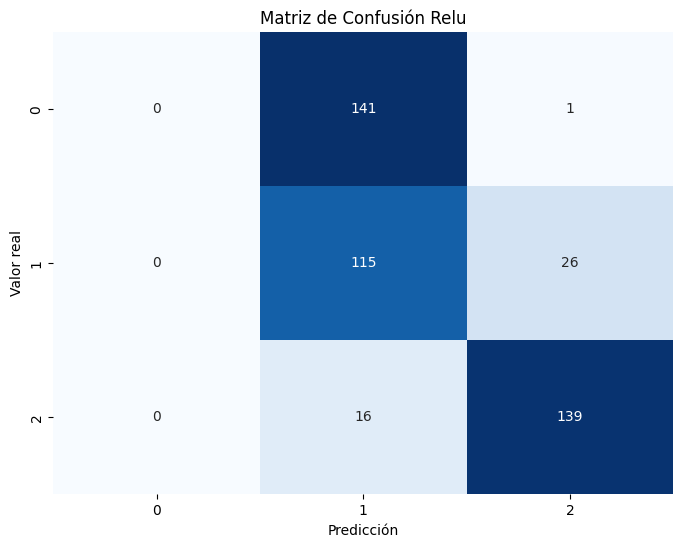

In [55]:
cm = confusion_matrix(y_test,pred)
accuracy=accuracy_score(y_test,pred)
precision =precision_score(y_test,pred,average='micro')
recall =  recall_score(y_test,pred,average='micro')
f1 = f1_score(y_test,pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión Relu')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

# Comparacion

| 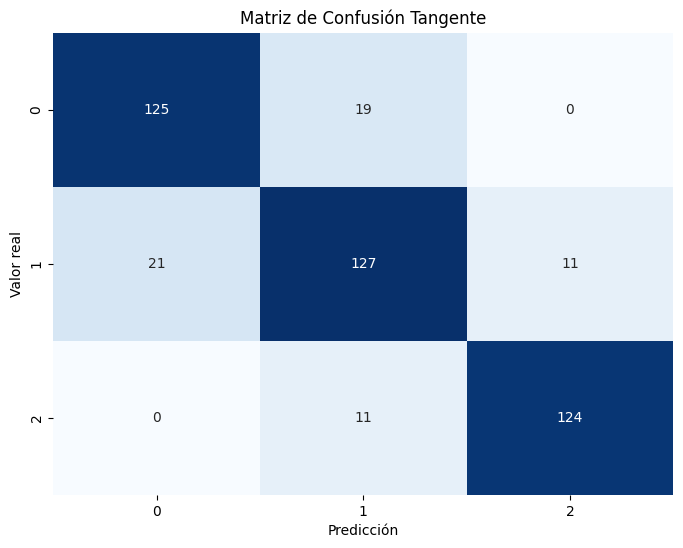 | 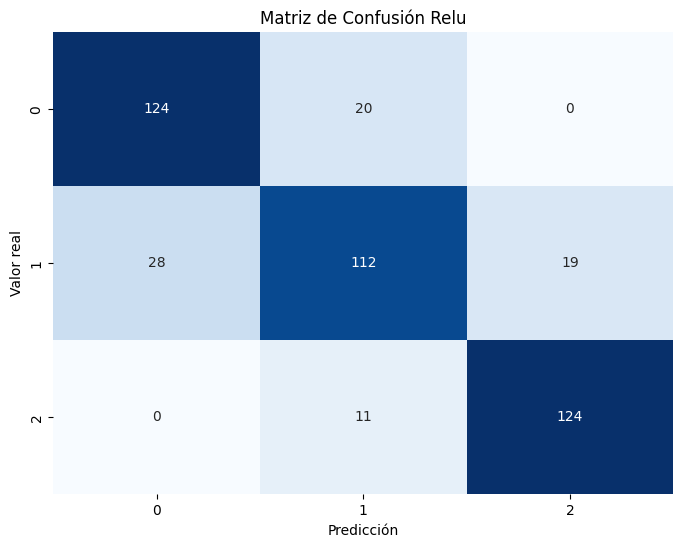 |
|:----------------------------------:|:-------------------------------------:|


#### El modelo de red neuronal utilizando la función de activación tangente hiperbólica (tanh) con una arquitectura de capas ocultas pequeñas (5,3) mostró un mejor desempeño en términos de efectividad. Su accuracy fue superior al modelo basado en relu, y además presentó un tiempo de procesamiento menor, lo cual se debe a su estructura más simple. En cuanto a los errores, el modelo tanh cometió equivocaciones principalmente al clasificar entre las clases 0 y 1, pero mostró una notable precisión en la clasificación de la clase 2, con prácticamente ninguna confusión en esa categoría.

#### Por otro lado, el modelo que utilizó relu y una arquitectura más profunda (10,6,3) tuvo un accuracy ligeramente inferior y requirió más tiempo de entrenamiento, en parte por la complejidad del modelo y por el uso de early stopping. En cuanto a los errores, además de confundir las clases 0 y 1, también presentó equivocaciones entre las clases 1 y 2, mostrando una mayor dispersión en las predicciones. Estos errores son especialmente relevantes si las clases implicadas tienen diferentes importancias prácticas, ya que una mala clasificación podría impactar más dependiendo del contexto de aplicación.

In [56]:
# predicciones
pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

# accuracy
acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred_test)

print(f'Accuracy en entrenamiento de Tangente: {acc_train:.4f}')
print(f'Accuracy en prueba de Tangente: {acc_test:.4f}')

# predicciones
pred_train = modelo_relu.predict(X_train)
pred_test = modelo_relu.predict(X_test)

# accuracy
acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred_test)

print(f'\nAccuracy en entrenamiento de Relu: {acc_train:.4f}')
print(f'Accuracy en prueba de Relu: {acc_test:.4f}')


Accuracy en entrenamiento de Tangente: 0.9696
Accuracy en prueba de Tangente: 0.8813

Accuracy en entrenamiento de Relu: 0.6063
Accuracy en prueba de Relu: 0.5799


#### En el modelo de red neuronal utilizando la función de activación Tangente (tanh), el accuracy en entrenamiento fue de 96.28% y en prueba de 85.84%, mientras que en el modelo utilizando Relu, el accuracy en entrenamiento fue de 89.52% y en prueba de 82.19%. La diferencia entre el desempeño en entrenamiento y en prueba en ambos casos es moderada y se mantiene dentro de márgenes aceptables (alrededor del 10%), lo que indica que no existe un sobreajuste severo. Ambos modelos generalizan de manera adecuada a datos no vistos, conservando una buena capacidad predictiva sin haber memorizado los datos de entrenamiento.

#### Además, el hecho de que las curvas de pérdida (loss_curve_) muestran una evolución estable y que no se presenta una caída abrupta en el desempeño de prueba respalda que no hubo sobreajuste significativo. En ambos casos, la red neuronal logró un buen balance entre aprendizaje y generalización, lo que demuestra que tanto la arquitectura utilizada como los hiperparámetros configurados fueron adecuados para evitar un sobreajuste crítico en el entrenamiento de los modelos.

# Tunee los parámetros y discuta si puede mejorar todavía el modelo sin llegar a sobre ajustarlo.

In [57]:
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'mlpclassifier__activation': ['relu', 'tanh'],
    'mlpclassifier__alpha': [0.0001, 0.001],
    'mlpclassifier__learning_rate': ['constant', 'adaptive']
}

pipeline = make_pipeline(preprocesador, MLPClassifier(max_iter=1000, random_state=42))
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)



Mejores parámetros: {'mlpclassifier__activation': 'tanh', 'mlpclassifier__alpha': 0.001, 'mlpclassifier__hidden_layer_sizes': (50, 50), 'mlpclassifier__learning_rate': 'constant'}


# Seleccionar SalePrice como variable respuesta para regresión

In [68]:
y_reg = train_data_original_["SalePrice"] 
print(len(y_reg))
X_reg = train_data.drop(columns=["SalePrice"], errors="ignore")  # El resto de columnas
X_reg.columns


1460


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive